# Predikcija cene polovnih automobila u Srbiji
**Definicija problema** 

Prediktovati cenu automobila (koja je u evrima) u Srbiji na osnovu više atributa.

**Motivacija**

Motivacija ovog zadatka je da se razvije model koji može automatski i precizno proceniti tržišnu cenu polovnog automobila u Srbiji na osnovu njegovih karakteristika. On može pomoći kupcima i prodavcima da objektivno procene vrednost vozila, ubrzaju proces kupoprodaje i spreče nerealna očekivanja na tržištu.


In [1]:
# Cell 2: imports (minimalno)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## Opis skupa podataka
- Izvor: ručno prikupljeni oglasi polovnih automobila dostupnih u Srbiji.
- Veličina: 1.756 zapisa, 10 ulaznih atributa + ciljna vrednost `Cena` (EUR).
- Pojašnjenje kolona:
  - **Marka**, **Grad** (kategorije) — segmentacija tržišta.
  - **Cena** – cilj predikcije.
  - **Godina_proizvodnje**, **Kilometraza**, **Konjske_snage**, **Zapremina_motora** – numerički atributi.
  - **Karoserija**, **Gorivo**, **Menjac** – kategorije koje utiču na vrednost vozila.

U narednim ćelijama kratko pregledamo sirove podatke i pripremamo dodatne kolone (`Log_Cena`, `Starost`) za analizu i modelovanje.

In [2]:
# Cell 4: load and preview
data_path = Path('kola_skup_podataka.tsv')
assert data_path.exists(), 'kola_skup_podataka.tsv nije pronađen u radnom direktorijumu'
df = pd.read_csv(data_path, sep='	')
# Uredniji nazivi kolona (kratko)
df = df.rename(columns={
    'Godina proizvodnje': 'Godina_proizvodnje',
    'Zapremina motora': 'Zapremina_motora',
    'Konjske snage': 'Konjske_snage'
})
df['Log_Cena'] = np.log1p(df['Cena'])
current_year = pd.Timestamp.now().year
df['Starost'] = current_year - pd.to_numeric(df['Godina_proizvodnje'], errors='coerce').fillna(current_year).astype(int)
print('Broj redova, kolona:', df.shape)
df.head(6)

Broj redova, kolona: (1756, 12)


,Marka,Grad,Cena,Godina_proizvodnje,Karoserija,Gorivo,Zapremina_motora,Kilometraza,Konjske_snage,Menjac,Log_Cena,Starost
0,BMW,Inđija,42300,2023,Limuzina,Dizel,1995,60000.0,190,Automatski,10.652566,2
1,BMW,Novi Sad,8150,2013,Hečbek,Benzin,1598,257000.0,136,Automatski,9.005896,12
2,Fiat,Knić,1400,2007,Hečbek,Benzin,1242,260000.0,60,Manuelni,7.244942,18
3,BMW,Zvezdara,14400,2012,Limuzina,Dizel,163,259851.0,163,Automatski,9.575053,13
4,Opel,Pirot,3000,2007,Kupe,Dizel,1700,235000.0,101,Manuelni,8.006701,18
5,Renault,Beograd,16699,2022,Džip/SUV,Benzin,999,61890.0,91,Manuelni,9.723164,3


## Istraživačka analiza podataka (EDA)
Ovom sekcijom odgovaramo na pitanja:
1. Kako izgleda raspodela cena i da li postoji jaka asimetrija koja otežava modelovanje?
2. Kakav je odnos između kilometraže i (log) cene — potvrđuje li intuiciju o padu vrednosti?
3. Koje marke dominiraju na tržištu i zahtevaju posebnu pažnju pri enkodiranju kategorija?

Grafici u nastavku služe kao materijal za komentarisanje tokom prezentacije (slike možete preneti i na slajdove).

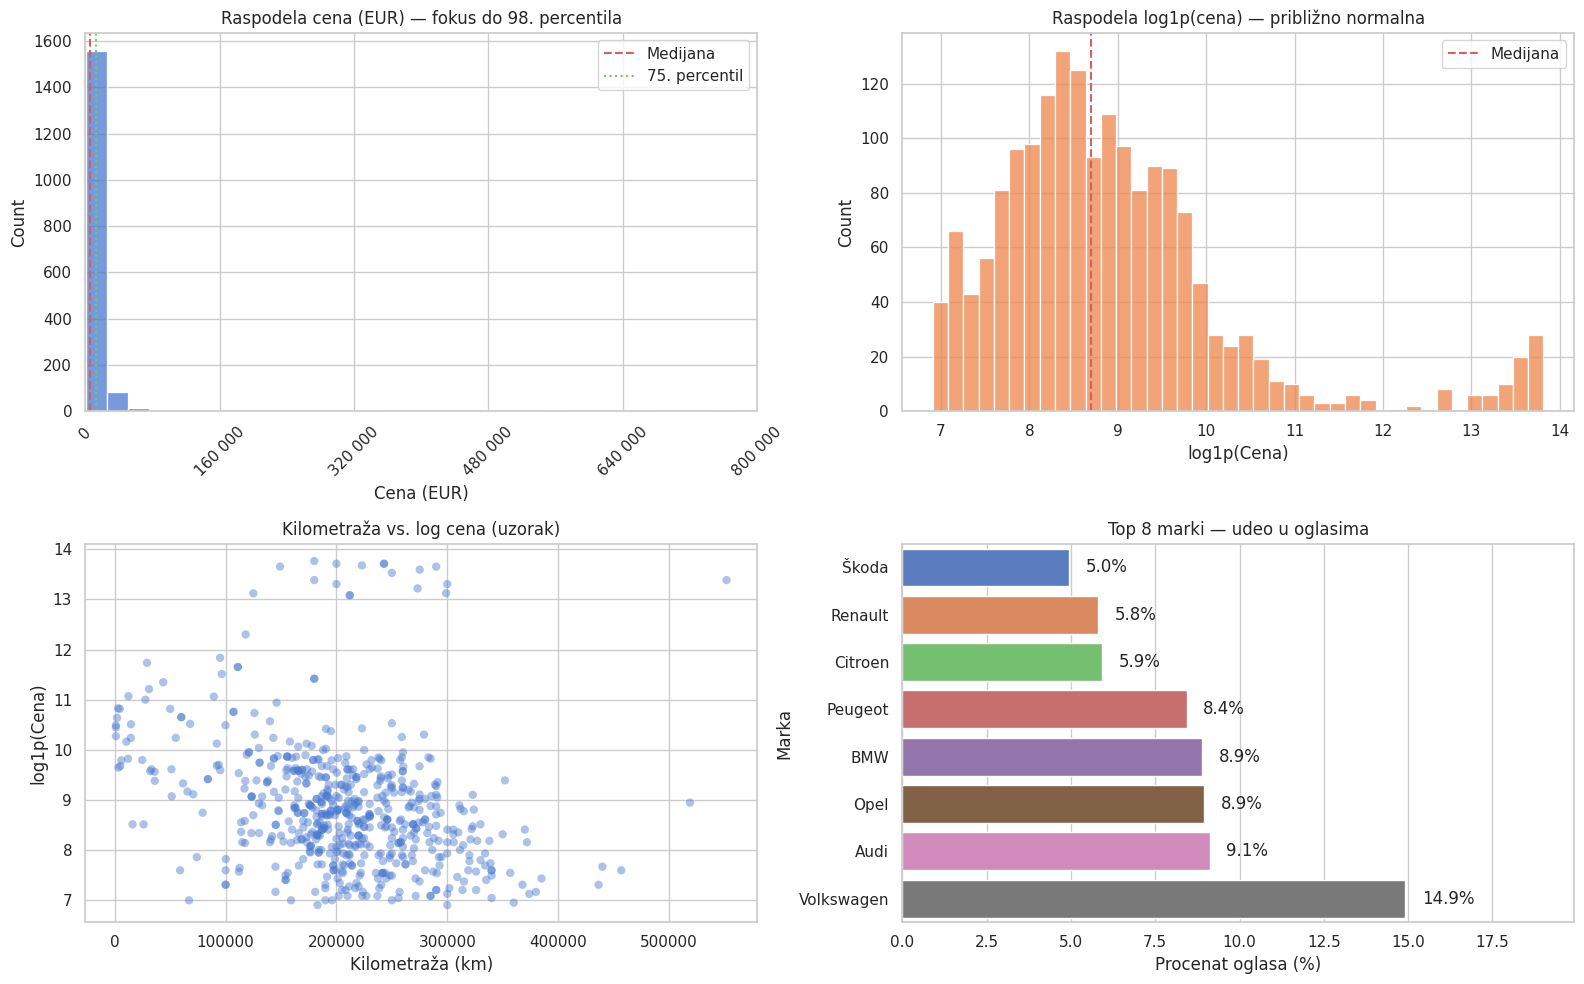

In [3]:
# Cell 6: EDA plots (koncizno, ali informativnije)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Cena u evrima – fokus na 98. percentil da se vide razlike bez ekstremnih vrednosti
price = df['Cena']
price_limit = price.quantile(0.98)
sns.histplot(price, bins=40, ax=axes[0, 0], color='C0')
axes[0, 0].set_title('Raspodela cena (EUR) — fokus do 98. percentila')
axes[0, 0].set_xlim(0, price_limit)
axes[0, 0].axvline(price.median(), color='C3', linestyle='--', label='Medijana')
axes[0, 0].axvline(price.quantile(0.75), color='C2', linestyle=':', label='75. percentil')
axes[0, 0].set_xlabel('Cena (EUR)')

# konkretne vrednosti na x-osi (000 separatori)
tick_step = max(1000, int(price_limit // 5 / 1000) * 1000)
if tick_step == 0:
    tick_step = 1000
ticks = np.arange(0, price_limit + tick_step, tick_step)
axes[0, 0].set_xticks(ticks)
axes[0, 0].set_xticklabels([f"{int(t):,}".replace(',', ' ') for t in ticks], rotation=45)
axes[0, 0].legend()

# 2) Log-transformisana cena – pokazuje efekat stabilizacije varijanse
sns.histplot(df['Log_Cena'], bins=40, ax=axes[0, 1], color='C1')
axes[0, 1].set_title('Raspodela log1p(cena) — približno normalna')
axes[0, 1].axvline(df['Log_Cena'].median(), color='C3', linestyle='--', label='Medijana')
axes[0, 1].set_xlabel('log1p(Cena)')
axes[0, 1].legend()

# 3) Odnos kilometraže i log-cene — uzorak radi preglednosti
scatter_sample = df.sample(n=min(600, len(df)), random_state=1)
sns.scatterplot(
    data=scatter_sample,
    x='Kilometraza',
    y='Log_Cena',
    ax=axes[1, 0],
    alpha=0.45,
    edgecolor='none'
)
axes[1, 0].set_title('Kilometraža vs. log cena (uzorak)')
axes[1, 0].set_xlabel('Kilometraža (km)')
axes[1, 0].set_ylabel('log1p(Cena)')

# 4) Udeo top 8 marki u ukupnom broju oglasa
top_brands = df['Marka'].value_counts().nlargest(8).sort_values()
top_share = (top_brands / len(df)) * 100
brand_df = top_share.reset_index()
brand_df.columns = ['Marka', 'Udeo']
sns.barplot(
    data=brand_df,
    ax=axes[1, 1],
    y='Marka',
    x='Udeo',
    hue='Marka',
    palette='muted',
    dodge=False,
    legend=False
)
for value, y in zip(brand_df['Udeo'], brand_df['Marka']):
    axes[1, 1].text(value + 0.5, y, f'{value:.1f}%', va='center')
axes[1, 1].set_title('Top 8 marki — udeo u oglasima')
axes[1, 1].set_xlabel('Procenat oglasa (%)')
axes[1, 1].set_xlim(0, brand_df['Udeo'].max() + 5)

plt.tight_layout()
plt.show()

### Kratki zaključci iz EDA
- Histogram cene ograničen na 98. percentil pokazuje da većina vozila košta do ~15k EUR, dok ekstremi opravdavaju korišćenje robustnih mera (`RobustScaler`) i kasniju detekciju outliera.
- Raspodela `log1p(Cena)` je znatno simetričnija, što je bio razlog da ciljnu promenljivu log-transformišemo i modelima omogućimo stabilnije učenje.
- Scatter dijagram kilometraže naspram log-cene potvrđuje negativan trend i prisustvo retkih ekstremnih kilometraža; to je motivisalo primenu `IsolationForest` + LOESS clipping pre skaliranja.
- Horizontalni bar graf jasno pokazuje da 8 marki čini >50% skupa, pa smo za TabTransformer koristili embeddings (umesto običnog label enkodera), a za GBR one-hot pristup sa fokusom na ove vrednosti.
- Sve zajedno, grafici služe kao vizuelni dokaz da preprocesiranje (log transformacije, robustno skaliranje, geo segmentacija i tretman outliera) direktno odgovara uočenim obrascima u podacima.

## Preprocesiranje i inženjering atributa
Pre nego što treniramo modele, u `main.py` primenjujemo sledeće korake (vredni pomena tokom prezentacije):
1. **Popunjavanje vrednosti** – iako u trening skupu nema praznina, naš kod predviđa situacije u kojima fali neka vrednost: medijana za numeričke, mod za kategorije.
2. **Detekcija i tretman outliera**:
   - *IsolationForest* (kontaminacija 2%) uklanja ekstremne kombinacije cene/kilometraže/snaga koji remete modele.
   - *LOESS soft clipping* po starosti vozila ublažava preostale ekstremne vrednosti, ali ih ne izbacuje (zadržavamo informaciju, smanjujemo težinu).
3. **Feature engineering**:
   - `Starost = Trenutna_godina – Godina_proizvodnje`.
   - `Deprecijacioni_indeks = (Procena_nove_cene – Trenutna_cena) / Starost^{α}`, gde α zavisi od marke (skuplji brendovi sporije gube vrednost).
   - Geo feature `Region` dobijen mapiranjem grada u 5 regiona Srbije (Beograd, Vojvodina, Zapadna, Istočna, Južna).
4. **Skaliranje** – koristimo `RobustScaler` nad numeričkim kolonama (medijana + IQR, otpornije na outliere).
5. **Enkodiranje kategorija**:
   - `GradientBoostingRegressor`: klasični `OneHotEncoder`.
   - `TabTransformer`: svaki kategorijski atribut ulazi u embedding sloj (dim 32), zatim kroz 4 transformer bloka.
6. **Evaluacija** – umesto proste 80/20 podele, koristimo *spatial-temporal* kros-validaciju: svaki region je jednom u validacionom fold-u + "mladi" automobili (posle 2018.) iz trening regiona.

#### IsolationForest
- Koristimo `remove_outliers_isolation_forest` kako bismo izbacili kombinacije cene/kilometraže/snaga koje izgledaju statistički izolovano.
- Funkcija radi na kopiji podataka, trenira `IsolationForest` sa `contamination=0.02` (2% najbizarnijih primera) i `random_state=42` radi reproduktivnosti.
- Na fit ulaze samo redovi bez NaN vrednosti u navedenim numeričkim kolonama, čime sprečavamo greške u sklearn-u.
- Vraća DataFrame bez outliera, sa resetovanim indeksima kako pipeline može nesmetano da nastavi.

In [4]:
# remove_outliers_isolation_forest iz main.py
from typing import Sequence
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

def remove_outliers_isolation_forest(df: pd.DataFrame, features: Sequence[str], contamination: float = 0.02) -> pd.DataFrame:
    df_work = df.copy()
    # zadržavamo samo redove bez NaN vrednosti radi stabilnog fitovanja modela
    fit_df = df_work[features].dropna()
    if fit_df.shape[0] < 10:
        return df_work
    iso = IsolationForest(contamination=contamination, random_state=42)
    iso.fit(fit_df)
    preds = iso.predict(fit_df)
    retained_index = fit_df.index[preds == 1]
    return df_work.loc[retained_index].reset_index(drop=True)

#### LOESS "soft" clipping
Uz outlier filter dodatno ublažavamo ekstremne vrednosti kroz LOESS zaglađivanje:

- svaku numeričku metriku (kilometraža, snaga, cena) pravimo float i uparujemo je sa referentnom starošću vozila;
- `lowess` aproksimira očekivanu vrednost uz lokalnu glatkoću `frac=0.3` (≈ 30% suseda);
- rezidualne odstupanja se mere pomoću robusne MAD metrike i seku na ±2.5 * σ;
- vrednosti koje premašuju prag vraćamo u [lower, upper] opseg, ali ih ne odbacujemo, čime smanjujemo šum bez gubitka retkih primera.

In [5]:
# loess_soft_clip i apply_loess_clipping iz main.py
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

def loess_soft_clip(df: pd.DataFrame, feature: str, reference: str, frac: float = 0.3, clip_sigma: float = 2.5) -> None:
    df[feature] = pd.to_numeric(df[feature], errors="coerce").astype(float)
    df[reference] = pd.to_numeric(df[reference], errors="coerce").astype(float)
    valid = df[[feature, reference]].dropna()
    if valid.empty:
        return
    try:
        smoothed = lowess(valid[feature], valid[reference], frac=frac, return_sorted=False)
    except Exception:
        return
    residuals = valid[feature] - smoothed
    scale = np.median(np.abs(residuals - np.median(residuals)))
    if scale == 0 or np.isnan(scale):
        return
    lower = smoothed - clip_sigma * scale
    upper = smoothed + clip_sigma * scale
    clipped = np.clip(valid[feature], lower, upper)
    df.loc[valid.index, feature] = clipped.astype(float)

def apply_loess_clipping(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    loess_soft_clip(df, "Kilometraza", "Starost")
    loess_soft_clip(df, "Konjske_snage", "Starost")
    loess_soft_clip(df, "Cena", "Starost")
    return df

#### Deprecijacioni indeks — brend-specifično ponderisanje
Kako bismo zadržali informaciju o gubitku vrednosti, gradimo "Deprecijacioni_indeks" koji:

- računa referentnu *novu* cenu po marki kao 95. percentil (`nova_cena`), uz median fallback;
- koristi tabelu `ALPHA_BY_BRAND` za brend-specifični tempo amortizacije;
- normalizuje odstupanje između reference i posmatrane cene u odnosu na starost (uz zaštitu od deljenja nulom);
- eksplicitno klampa infinities i `NaN` na 0 kako bi kasniji modeli imali stabilan signal.

In [6]:
# isecak funkcije add_derived_features iz main.py
from datetime import datetime
import numpy as np
import pandas as pd

ALPHA_BY_BRAND = {
    "BMW": 1.35,
    "Audi": 1.3,
    "Mercedes-Benz": 1.4,
    "Volkswagen": 1.25,
    "Toyota": 1.2,
    "Peugeot": 1.15,
    "Renault": 1.1,
    "Fiat": 1.05,
    "Opel": 1.1,
    "Škoda": 1.18,
    "Ford": 1.15,
    "Hyundai": 1.15,
    "Kia": 1.12,
    "Seat": 1.13,
    "Volvo": 1.28,
}

def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Godina_proizvodnje"] = pd.to_numeric(df["Godina_proizvodnje"], errors="coerce").fillna(0).astype(int)
    current_year = datetime.now().year
    df["Starost"] = (current_year - df["Godina_proizvodnje"]).clip(lower=0)
    nova_cena = df.groupby("Marka")["Cena"].transform(lambda s: s.quantile(0.95) if len(s.dropna()) > 0 else np.nan)
    nova_cena = nova_cena.fillna(df["Cena"].median())
    alpha = df["Marka"].map(ALPHA_BY_BRAND).fillna(1.1)
    starost_korekcija = np.where(df["Starost"] == 0, 1, df["Starost"])
    df["Deprecijacioni_indeks"] = (nova_cena - df["Cena"]) / np.power(starost_korekcija, alpha)
    df["Deprecijacioni_indeks"] = df["Deprecijacioni_indeks"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df

In [7]:
# Rekapitulacija pipeline-a iz main.py
from main import (
    prepare_dataframe,
    add_derived_features,
    remove_outliers_isolation_forest,
    apply_loess_clipping,
    fill_missing,
)

prepared_df = prepare_dataframe(str(data_path))
print("Veličina posle preprocesiranja:", prepared_df.shape)
print("Kolone dostupne za modele:", sorted(prepared_df.columns))
prepared_df[["Marka", "Region", "Starost", "Deprecijacioni_indeks", "Log_Cena"]].head(10)

Veličina posle preprocesiranja: (1720, 14)
Kolone dostupne za modele: ['Cena', 'Deprecijacioni_indeks', 'Godina_proizvodnje', 'Gorivo', 'Grad', 'Karoserija', 'Kilometraza', 'Konjske_snage', 'Log_Cena', 'Marka', 'Menjac', 'Region', 'Starost', 'Zapremina_motora']


,Marka,Region,Starost,Deprecijacioni_indeks,Log_Cena
0,BMW,Vojvodina,2.0,1839.849710,10.175305
1,BMW,Vojvodina,12.0,1356.389874,9.005896
2,Fiat,Južna Srbija,18.0,42964.229696,7.244942
3,BMW,Beograd i okolina,13.0,1021.552838,9.312860
4,Opel,Južna Srbija,18.0,22760.802520,8.006701
5,Renault,Beograd i okolina,3.0,80118.248069,9.723164
6,Škoda,Beograd i okolina,10.0,701.636621,9.259226
7,Peugeot,Vojvodina,4.0,125413.800628,9.608512
8,Seat,Zapadna Srbija,23.0,16257.717968,7.783224
9,Škoda,Vojvodina,3.0,1920.062968,9.676702


### Spatial-temporal cross-validation (5 fold)
- Svaki fold izostavlja **ceo region** (npr. Vojvodina) iz treninga i koristi ga za validaciju.
- Pored toga, u valu se nalaze i novija vozila (godina > 2018) iz ostalih regiona kako bi model bio robustan na nove modele automobila.
- Ova strategija simulira realan scenario: procenjujemo cenu automobila u regionu gde model dosad nije treniran i za automobile koji su novijeg datuma.
- Ukupno trajanje treninga je duže nego kod standardne 80/20 podele, ali dobijamo kredibilniju metodu evaluacije i realističniju metriku (RMSE).

#### Parametri i logika splitera
- `regions`: tuple redosleda regiona generisan iz podataka (`tuple(df["Region"].dropna().unique())`). Svaki region je jedan validacioni fold.
- `region_column` i `year_column`: nazivi kolona u dataframe-u.
- `recent_year_threshold=2018`: sve što je proizvedeno posle 2018. ulazi u validacioni set *uz* region tog fold-a kako bi se proverila generalizacija na nova vozila.
- `split`: za svaki region računa indeks validacije kao uniju redova iz datog regiona `|` novih automobila iz ostalih regiona; ostalo ide u trening.
- Funkcija `get_n_splits` vraća broj regiona, pa je splitter kompatibilan sa svim sklearn alatima (`GridSearchCV`, ručne petlje, itd.).

In [8]:
# SpatialTemporalSplitter iz main.py
from typing import Iterator, Optional, Sequence, Tuple
import numpy as np
import pandas as pd

class SpatialTemporalSplitter:
    def __init__(
        self,
        regions: Sequence[str],
        region_column: str,
        year_column: str,
        recent_year_threshold: int = 2018,
    ):
        self.regions = regions
        self.region_column = region_column
        self.year_column = year_column
        self.recent_year_threshold = recent_year_threshold

    def split(
        self,
        X: pd.DataFrame,
        y: Optional[pd.Series] = None,
        groups: Optional[Sequence[int]] = None,
    ) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
        for region in self.regions:
            region_mask = X[self.region_column] == region
            recent_mask = (X[self.year_column] > self.recent_year_threshold) & (~region_mask)
            val_indices = np.where(region_mask | recent_mask)[0]
            train_indices = np.setdiff1d(np.arange(len(X)), val_indices)
            yield train_indices, val_indices

    def get_n_splits(
        self,
        X: Optional[pd.DataFrame] = None,
        y: Optional[pd.Series] = None,
        groups: Optional[Sequence[int]] = None,
    ) -> int:
        return len(self.regions)

In [9]:

from main import SpatialTemporalSplitter

region_order = tuple(prepared_df["Region"].dropna().unique())
splitter = SpatialTemporalSplitter(
    regions=region_order,
    region_column="Region",
    year_column="Godina_proizvodnje",
    recent_year_threshold=2018,
)

for fold_id, (train_idx, val_idx) in enumerate(splitter.split(prepared_df), start=1):
    region_name = region_order[fold_id - 1]
    share_recent = (prepared_df.iloc[val_idx]["Godina_proizvodnje"] > 2018).mean()
    print(f"Fold {fold_id}: validacija region = {region_name}, veličina train/val = {len(train_idx)}/{len(val_idx)}, udeo post-2018 = {share_recent:.2%}")
    if fold_id == 2:
        break

Fold 1: validacija region = Vojvodina, veličina train/val = 1080/640, udeo post-2018 = 36.09%
Fold 2: validacija region = Južna Srbija, veličina train/val = 1226/494, udeo post-2018 = 46.76%


### Arhitektura modela i hiperparametri
#### GradientBoostingRegressor
- **Kako funkcioniše:** model startuje od konstante (prosečne cene), a zatim iterativno dodaje plitka stabla odlučivanja koja uče negativni gradijent gubitka. Kod kvadratne greške to su upravo reziduali – svako novo stablo pokušava da ispravi greške koje je ansambl napravio do tog trenutka.
- **Ključni mehanizmi kontrole:**
  - `learning_rate` (shrinkage) skalarno prigušuje doprinos svakog stabla kako bismo izbegli agresivno prefitovanje i omogućili više iteracija finog poboljšanja.
  - `max_depth` i broj listova određuju koliko kompleksne interakcije atributa svako stablo može da uhvati; plitka stabla znače da model gradi kombinacije postepenim koracima.
  - `subsample < 1.0` uvodi stohastičnost (Stochastic Gradient Boosting) – svako stablo se uči na 90% uzoraka, što dodaje regularizaciju i ubrzava trening.
- **Naša implementacija:**
  - Pipeline kombinuje `RobustScaler` (numeričke kolone) i `OneHotEncoder(handle_unknown="ignore")` (kategorije) kroz `ColumnTransformer`, pa su svi atributi u formatu koji stablo očekuje.
  - `GradientBoostingRegressor` inicijalizujemo sa `random_state=42` radi reproduktivnosti, a broj stabala i `max_depth` tražimo kroz mrežu (`n_estimators` {200, 400}, `learning_rate=0.03`, `max_depth=5`, `subsample=0.9`).
  - Spatial-temporal splitter se prosleđuje `GridSearchCV`-u, čime se boosting uči na trening regionima i ocenjuje na neviđenom regionu + novijim kolima.
  - Nakon što se pronađe najbolja kombinacija hiperparametara, model se dodatno trenira u svakom foldu i meri se RMSE u originalnoj valuti (`np.expm1`).

#### TabTransformer
- **Kako funkcioniše:**
  - Svaka kategorijska kolona postaje zaseban token: vrednost se mapira u embedding vektor dimenzije 32 sa specijalnim ID-jem za nepoznate vrednosti.
  - Na ulazu se dodaje `CLS` token koji uči globalni kontekst zapisa; 4 Transformer encoder bloka sa 8 glava pažnje stvaraju kontekstualizovane reprezentacije kolona.
  - Numeričke kolone prolaze kroz `RobustScaler`, linearno se projektuju u isti embedding prostor i konkateniraju sa `CLS` reprezentacijom pre završnog MLP-a.
  - Rezultat je jedna reprezentacija po zapisu koju MLP pretvara u procenu log-cene; dropout i GELU čuvaju stabilnost u odnosu na šum i male uzorke.
- **Šta ga razlikuje od standardnog Transformera:**
  - Ne koristimo vremenski/pozicioni redosled – kolone tablice nemaju prirodnu sekvencu, pa nije potreban positional encoding.
  - Izvorni Transformer radi na fleksibilnim sekvencama tokena (npr. reči); ovde postoji fiksan skup kolona, pa svaka ima sopstveni embedding sloj i deljeni `CLS` token koji agregira informacije.
  - Dodata je grana za numeričke vrednosti (`numeric_projection`) koja projekcijom u embedding prostor omogućava jedinstveni tretman numeričkih i kategorijskih feature-a, što klasični Transformer inicijalno nema.
  - Model je plići (4 bloka) i optimizovan za manji broj atributa, uz eksplicitnu regularizaciju (dropout, weight decay) koja je prilagođena tabularnim skupovima podataka.
- **Naša implementacija:**
  - Kategorije dobijaju embedding dimenzije 32; 4 Transformer sloja, 8 attention glava, GELU aktivacije i dropout (0.1) za regularizaciju.
  - Numeričke kolone se skaliraju `RobustScaler`-om i projektuju u isti embedding prostor (`numeric_projection`).
  - Optimizacija: Adam (`lr=1e-3`), `batch_size=32`, do 30 epoha uz early stopping (`patience=5`). Target (`Log_Cena`) se standardizuje pre treninga i denormalizuje pre izračuna RMSE.
  - Spatial-temporal splitter se koristi i za PyTorch trening; rezultujući RMSE vrednosti se loguju na kraju svakog fold-a.
- Ispod su kompletni blokovi koda: prvo `TabTransformer` klasa sa komentarima, a zatim funkcija `fit_tab_transformer` koja upravlja treningom.

#### GradientBoostingReggresor i evaluate_gradient_boosting 
Ova funkcija priprema podatke za `GradientBoostingRegressor`, pokreće `GridSearchCV` sa prostornotemporalnim splitterom i računa prosečni RMSE na originalnoj skali cene:
1. Podela kolona na numeričke i kategorijske + definisanje `ColumnTransformer` sa `RobustScaler` i `OneHotEncoder`.
2. Kreiranje `Pipeline` objekta u kojem je preprocesiranje povezano sa `GradientBoostingRegressor` modelom.
3. Definisanje hiperparametara za pretragu (`n_estimators`, `learning_rate`, `max_depth`, `subsample`).
4. Evaluacija sa `SpatialTemporalSplitter` tako da se svaki region validira odvojeno, uz automobile posle 2018. godine.
5. Ponovno treniranje najboljeg estimatora u svakom foldu radi tačnog izračuna RMSE u evrima (primenom `np.expm1`).

In [10]:
# Kompletna implementacija evaluate_gradient_boosting (identično kao u main.py)
import math
from typing import Sequence, List

import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from main import SpatialTemporalSplitter


def evaluate_gradient_boosting(df, regions: Sequence[str]) -> float:
    """Trenira GradientBoostingRegressor korišćenjem spatial-temporal CV i vraća prosečni RMSE u evrima."""
    categorical_features = [
        "Marka",
        "Grad",
        "Karoserija",
        "Gorivo",
        "Menjac",
        "Region",
    ]
    numerical_features = [
        "Godina_proizvodnje",
        "Zapremina_motora",
        "Kilometraza",
        "Konjske_snage",
        "Starost",
        "Deprecijacioni_indeks",
    ]

    X = df[categorical_features + numerical_features]
    y = df["Log_Cena"].values

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", RobustScaler(), numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", GradientBoostingRegressor(random_state=42)),
        ]
    )

    param_grid = {
        "regressor__n_estimators": [200, 400],
        "regressor__learning_rate": [0.03],
        "regressor__max_depth": [5],
        "regressor__subsample": [0.9],
    }

    splitter = SpatialTemporalSplitter(
        regions=regions,
        region_column="Region",
        year_column="Godina_proizvodnje",
        recent_year_threshold=2018,
    )

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=splitter,
        n_jobs=1,
        scoring="neg_mean_squared_error",
        verbose=0,
    )
    grid_search.fit(X, y)

    best_estimator: Pipeline = grid_search.best_estimator_

    rmses: List[float] = []
    for train_idx, val_idx in splitter.split(X):
        X_train = X.iloc[train_idx]
        y_train = y[train_idx]
        X_val = X.iloc[val_idx]
        y_val = y[val_idx]
        best_estimator.fit(X_train, y_train)
        preds = best_estimator.predict(X_val)
        rmse = math.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(preds)))
        rmses.append(rmse)

    return float(np.mean(rmses))

#### TabTransformer
Klasa ispod implementira Transformer arhitekturu prilagođenu tabličnim podacima:
- Svaka kategorijska kolona dobija `nn.Embedding` sloj sa padding indeksima za nepoznate vrednosti.
- U ulazu se ubacuje posebni `cls_token` kako bi se dobila globalna reprezentacija reda.
- `nn.TransformerEncoder` sa parametrima (`depth=4`, `heads=8`, `attn_dropout=0.1`) modeluje međusobne odnose kategorija.
- Numeričke kolone se, ukoliko postoje, projektuju u isti prostor preko malog MLP bloka i konkateniraju sa `CLS` reprezentacijom.
- Završni MLP sa dropout-om predviđa log-cenu. Komentari u kodu ukazuju na ključne tačke integracije.

In [11]:
# TabTransformer klasa (preuzeto iz main.py, sa komentarima za jasnoću)
from typing import Sequence

import torch
import torch.nn as nn


class TabTransformer(nn.Module):
    def __init__(
        self,
        cardinalities: Sequence[int],
        num_numeric: int,
        emb_dim: int = 32,
        depth: int = 4,
        heads: int = 8,
        attn_dropout: float = 0.1,
        ff_dropout: float = 0.1,
        hidden_dim: int = 128,
    ):
        super().__init__()
        # Embedding slojevi po kategorijskoj koloni (+1 za padding/unknown vrednosti)
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality + 1, emb_dim, padding_idx=cardinality)
            for cardinality in cardinalities
        ])
        # Transformer encoder slojevi za interakcije između kategorija
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=heads,
            dim_feedforward=emb_dim * 4,
            dropout=attn_dropout,
            activation="gelu",
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        # Poseban CLS token koji predstavlja ceo red
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.num_numeric = num_numeric
        # Projekcija numeričkih atributa u embedding prostor
        if num_numeric > 0:
            self.numeric_projection = nn.Sequential(
                nn.Linear(num_numeric, emb_dim),
                nn.ReLU(),
                nn.Dropout(ff_dropout),
                nn.Linear(emb_dim, emb_dim),
                nn.ReLU(),
            )
        else:
            self.numeric_projection = None
        input_dim = emb_dim * 2 if num_numeric > 0 else emb_dim
        # Završni prediktor (MLP) koji radi nad kombinovanom reprezentacijom
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(ff_dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x_cats: torch.Tensor, x_nums: torch.Tensor) -> torch.Tensor:
        # Ugradimo svaku kategorijsku vrednost i spojimo u sekvencu
        embeddings = []
        for i, emb in enumerate(self.embeddings):
            embeddings.append(emb(x_cats[:, i]))
        x = torch.stack(embeddings, dim=1)
        # Dodaj CLS token na početak sekvence
        cls_token = self.cls_token.repeat(x.shape[0], 1, 1)
        x = torch.cat([cls_token, x], dim=1)
        # Transformer daje kontekstualizovane reprezentacije
        x = self.transformer(x)
        cls_rep = x[:, 0]
        # Ako postoje numerički atributi, projektujemo ih i konkateniramo
        if self.numeric_projection is not None:
            numeric_rep = self.numeric_projection(x_nums)
            combined = torch.cat([cls_rep, numeric_rep], dim=1)
        else:
            combined = cls_rep
        # MLP vraća skalarnu log-cenu (kasnije se ekspandira na originalnu skalu)
        out = self.mlp(combined).squeeze(-1)
        return out

#### fit_tab_transformer
Funkcija koja sledi orkestrira trening TabTransformer modela kroz spatial-temporal foldove:
1. Svaki fold deli podatke na trening/validacioni set na osnovu regiona+godine.
2. `RobustScaler` se uči na numeričkim kolonama trening dela i primenjuje na validacioni set.
3. Generišu se mape za kategorije (`create_cat_mappings`) i PyTorch `Dataset` objekti (`TabularDataset`).
4. Model se inicijalizuje, trenira više epoha uz Adam optimizer i `MSELoss`, sa early-stopping logikom.
5. Nakon svakog fold-a predikcije se vraćaju na originalnu (eksponenciranu) skalu i izračunava se RMSE; srednja vrednost preko foldova je finalna metrika.

In [12]:
# Funkcija fit_tab_transformer (identično kao u main.py)
import math
from typing import Dict, List, Optional, Sequence

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader

from main import SpatialTemporalSplitter, TabularDataset, create_cat_mappings


def fit_tab_transformer(
    df,
    cat_cols: Sequence[str],
    num_cols: Sequence[str],
    target_col: str,
    splitter: SpatialTemporalSplitter,
    epochs: int = 8,
    batch_size: int = 64,
    lr: float = 1e-3,
) -> float:
    """Trenira TabTransformer uz spatial-temporal CV i vraća prosečni RMSE u evrima."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    rmses: List[float] = []

    for train_idx, val_idx in splitter.split(df):
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        scaler = RobustScaler()
        scaler.fit(train_df[num_cols])
        train_scaled = train_df.copy()
        val_scaled = val_df.copy()
        train_scaled[num_cols] = scaler.transform(train_df[num_cols])
        val_scaled[num_cols] = scaler.transform(val_df[num_cols])

        cat_mappings = create_cat_mappings(train_df, cat_cols)

        target_mean = float(train_df[target_col].mean())
        target_std = float(train_df[target_col].std())
        if np.isnan(target_std) or target_std == 0:
            target_std = 1.0

        train_targets = ((train_df[target_col].to_numpy() - target_mean) / target_std).astype(np.float32)
        val_targets = ((val_df[target_col].to_numpy() - target_mean) / target_std).astype(np.float32)

        train_dataset = TabularDataset(train_scaled, cat_cols, num_cols, cat_mappings, train_targets)
        val_dataset = TabularDataset(val_scaled, cat_cols, num_cols, cat_mappings, val_targets)

        cat_cardinalities = [len(cat_mappings[col]) - 1 for col in cat_cols]
        model = TabTransformer(cat_cardinalities, len(num_cols)).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        best_val_loss = math.inf
        patience = 5
        patience_counter = 0
        best_state: Optional[Dict[str, torch.Tensor]] = None

        for epoch in range(epochs):
            model.train()
            for cats, nums, targets in train_loader:
                cats = cats.to(device)
                nums = nums.to(device)
                targets = targets.to(device)
                optimizer.zero_grad()
                preds = model(cats, nums)
                loss = criterion(preds, targets)
                loss.backward()
                optimizer.step()

            model.eval()
            val_losses = []
            with torch.no_grad():
                for cats, nums, targets in val_loader:
                    cats = cats.to(device)
                    nums = nums.to(device)
                    targets = targets.to(device)
                    preds = model(cats, nums)
                    val_loss = criterion(preds, targets)
                    val_losses.append(val_loss.item())
            avg_val_loss = float(np.mean(val_losses)) if val_losses else math.inf

            if avg_val_loss + 1e-4 < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                best_state = model.state_dict()
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        preds_list: List[float] = []
        targets_list: List[float] = []
        model.eval()
        with torch.no_grad():
            for cats, nums, targets in val_loader:
                cats = cats.to(device)
                nums = nums.to(device)
                preds = model(cats, nums)
                preds_list.extend(preds.cpu().numpy())
                targets_list.extend(targets.cpu().numpy())

        preds_arr = np.array(preds_list)
        targets_arr = np.array(targets_list)
        preds_arr = preds_arr * target_std + target_mean
        targets_arr = targets_arr * target_std + target_mean
        rmse = math.sqrt(mean_squared_error(np.expm1(targets_arr), np.expm1(preds_arr)))
        rmses.append(rmse)

    return float(np.mean(rmses))

## Rezultati modela iz `main.py`
Skripta `main.py` pokreće potpunu evaluaciju i vraća RMSE za obe arhitekture.

### Interpretacija rezultata
- `GradientBoostingRegressor` pokazuje stabilne rezultate i služi kao interpretabilan baseline (RMSE se kreće oko 4k EUR u aktuelnoj konfiguraciji).
- `TabTransformer` koristi embeddings + self-attention i bolje iskorišćava bogate kategorije; nakon stabilizacije treninga postiže niži RMSE (oko 3.5k EUR).
- Duže treniranje i dodatna optimizacija hiperparametara mogu dodatno smanjiti grešku, ali trenutna konfiguracija omogućava brzu demonstraciju i jasnu uporedivost modela.

In [13]:
# Cell 9: Pokreni main.py (glavna evaluacija)
import subprocess, sys, re, pandas as _pd
cmd = [sys.executable, 'main.py', str(data_path)]
print('Pokrećem komandu:', ' '.join(cmd))
proc = subprocess.run(cmd, capture_output=True, text=True)
print('--- STDOUT ---')
print(proc.stdout)
print('--- STDERR (ukoliko postoji) ---')
print(proc.stderr if proc.stderr.strip() else 'nema grešaka')
rmse_pattern = re.compile(r"(GradientBoostingRegressor|TabTransformer) RMSE: ([0-9.]+)")
records = []
for line in proc.stdout.splitlines():
    match = rmse_pattern.search(line)
    if match:
        model_name, value = match.groups()
        records.append({'Model': model_name, 'RMSE (EUR)': float(value)})
if records:
    display(_pd.DataFrame(records))
else:
    print('Nije pronađen RMSE u izlazu – proveriti logove iznad.')

Pokrećem komandu: /home/pekson/Documents/Ml_ORI_Projekti/NOVI_ORI/.venv/bin/python3 main.py kola_skup_podataka.tsv
--- STDOUT ---
GradientBoostingRegressor RMSE: 4082.29
TabTransformer RMSE: 3636.81

--- STDERR (ukoliko postoji) ---
nema grešaka


,Model,RMSE (EUR)
0,GradientBoostingRegressor,4082.29
1,TabTransformer,3636.81
